In [1]:
import os
if 'google.colab' in str(get_ipython()):
    if not os.path.exists('maser-research'):
        !git clone https://github.com/spragunr/maser-research
    os.chdir('maser-research')

Cloning into 'maser-research'...
remote: Enumerating objects: 58, done.
remote: Counting objects: 100% (58/58), done.
remote: Compressing objects: 100% (44/44), done.
remote: Total 58 (delta 20), reused 50 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (58/58), 1009.80 KiB | 11.47 MiB/s, done.
Resolving deltas: 100% (20/20), done.


In [2]:
import sys, os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
for p in ("src", "../src"):
    ap = os.path.abspath(p)
    if ap not in sys.path:
        sys.path.insert(0, ap)

import numpy as np
import matplotlib.pyplot as plt
import synth_data as sd
from maser_data import FEATURES, TARGET

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
from xgboost import XGBClassifier

In [3]:
df = sd.make_dataset(plane="xray", scenario="wedge", seed=0)
print("columns:", list(df.columns))
print("synthetic dataset configuration:")
df.head()

columns: ['L_12um_bestfit_1', 'Lob', 'is_megamaser_plus', 'Lum_dis', 'z_true', 'detected', 'p_true', 'p_obs']
synthetic dataset configuration:


,L_12um_bestfit_1,Lob,is_megamaser_plus,Lum_dis,z_true,detected,p_true,p_obs
0,43.452325,42.058147,0,115.73,0,1,0.111001,0.111001
1,43.946954,41.226638,0,213.90,0,1,0.325619,0.325619
2,39.812201,39.691107,0,18.36,0,1,0.002327,0.002327
3,44.174294,43.924343,0,275.28,0,1,0.005964,0.005964
4,42.554714,42.303903,0,191.79,0,1,0.077252,0.077252


In [4]:
# ---- fixed experiment config (identical for every model) ----
PLANE     = "xray"
SCENARIOS = ["linear", "wedge", "box", "interaction", "blob"]
STRENGTH  = 3.0
N_AT      = 50
SEEDS     = range(5)
OUTER_SPLITS, OUTER_REPEATS = 5, 3
FEATS, TGT = FEATURES[PLANE], TARGET[PLANE]

METRICS = ["auc", "pr_auc", "brier", "prec_at_n", "mse_vs_truth"]
HIGHER_BETTER = {"auc": True, "pr_auc": True, "prec_at_n": True,
                 "brier": False, "mse_vs_truth": False}

# ---- model builders (each returns a fresh estimator per fold) ----
def make_lr(features="plain", C=1.0):
    def build():
        steps = [StandardScaler()]
        if features == "interaction":
            steps.append(PolynomialFeatures(2, interaction_only=True, include_bias=False))
        elif features == "quadratic":
            steps.append(PolynomialFeatures(2, interaction_only=False, include_bias=False))
        steps.append(LogisticRegression(C=C, solver="liblinear", max_iter=1000))
        return make_pipeline(*steps)
    return build

def make_rf():
    return lambda: RandomForestClassifier(
        n_estimators=300, max_depth=4, min_samples_leaf=5, random_state=0, n_jobs=1)

def make_xgb():
    return lambda: XGBClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric="logloss", random_state=0, n_jobs=1, tree_method="hist")

MODELS = {
    "lr_linear":    make_lr("plain"),      # baseline
    "lr_quadratic": make_lr("quadratic"),
    "rf":           make_rf(),
    "xgb":          make_xgb(),
}

# ---- scoring harness ----
def evaluate(build, scenario):
    """Mean over seeds of (mean-over-folds metrics + pooled prec@N)."""
    per_seed = []
    for s in SEEDS:
        d = sd.make_dataset(PLANE, scenario=scenario, strength=STRENGTH, seed=s)
        X, y, p_true = d[FEATS].to_numpy(), d[TGT].to_numpy(), d["p_true"].to_numpy()
        fold_rows, y_pool, p_pool = [], [], []
        for r in range(OUTER_REPEATS):
            skf = StratifiedKFold(OUTER_SPLITS, shuffle=True, random_state=r)
            for tr, te in skf.split(X, y):
                m = build().fit(X[tr], y[tr])
                p = m.predict_proba(X[te])[:, 1]
                fold_rows.append({
                    "auc": roc_auc_score(y[te], p),
                    "pr_auc": average_precision_score(y[te], p),
                    "brier": np.mean((p - y[te]) ** 2),
                    "mse_vs_truth": np.mean((p - p_true[te]) ** 2),
                })
                y_pool.append(y[te]); p_pool.append(p)
        row = pd.DataFrame(fold_rows).mean()
        y_pool, p_pool = np.concatenate(y_pool), np.concatenate(p_pool)
        row["prec_at_n"] = y_pool[np.argsort(-p_pool)[:N_AT]].mean()
        per_seed.append(row)
    return pd.DataFrame(per_seed).mean().to_dict()



In [5]:
# ---- LR hyperparameter sweep: {plain, interaction, quadratic} x C in {.1, 1, 10} ----
# Reruns the shared evaluate() harness over the LR grid to show WHY the chosen
# LR config was selected. One table per metric: configs x scenarios + MEAN/WORST.
import itertools

LR_GRID = {
    f"{feat}_C{C}": make_lr(features=feat, C=C)
    for feat, C in itertools.product(["plain", "interaction", "quadratic"], [0.1, 1.0, 10.0])
}

sweep_rows = []
for name, build in LR_GRID.items():
    for sc in SCENARIOS:
        out = evaluate(build, sc)
        sweep_rows.append({"config": name, "scenario": sc,
                           **{m: out[m] for m in METRICS}})
sweep = pd.DataFrame(sweep_rows)

def sweep_table(metric):
    hb = HIGHER_BETTER[metric]
    t = sweep.pivot(index="config", columns="scenario", values=metric)[SCENARIOS]
    t["MEAN"]  = t.mean(axis=1)
    t["WORST"] = t.min(axis=1) if hb else t.max(axis=1)
    return t.sort_values("MEAN", ascending=not hb).round(3)

for m in METRICS:
    print(f"\n===== {m}  (higher better: {HIGHER_BETTER[m]}) =====")
    display(sweep_table(m))


===== auc  (higher better: True) =====


scenario,linear,wedge,box,interaction,blob,MEAN,WORST
config,,,,,,,
quadratic_C1.0,0.827,0.851,0.770,0.836,0.878,0.832,0.770
quadratic_C10.0,0.831,0.848,0.766,0.834,0.876,0.831,0.766
quadratic_C0.1,0.781,0.846,0.783,0.831,0.877,0.824,0.781
interaction_C10.0,0.836,0.841,0.767,0.841,0.777,0.812,0.767
interaction_C1.0,0.832,0.842,0.770,0.841,0.777,0.812,0.770
interaction_C0.1,0.797,0.841,0.778,0.841,0.777,0.807,0.777
plain_C10.0,0.840,0.746,0.749,0.736,0.492,0.713,0.492
plain_C1.0,0.840,0.747,0.748,0.736,0.491,0.712,0.491
plain_C0.1,0.833,0.746,0.746,0.735,0.489,0.710,0.489



===== pr_auc  (higher better: True) =====


scenario,linear,wedge,box,interaction,blob,MEAN,WORST
config,,,,,,,
quadratic_C1.0,0.420,0.448,0.373,0.425,0.397,0.413,0.373
quadratic_C10.0,0.416,0.447,0.367,0.425,0.391,0.409,0.367
quadratic_C0.1,0.388,0.447,0.395,0.405,0.387,0.404,0.387
interaction_C1.0,0.426,0.418,0.368,0.434,0.190,0.367,0.190
interaction_C10.0,0.427,0.418,0.362,0.433,0.190,0.366,0.190
interaction_C0.1,0.406,0.416,0.386,0.429,0.190,0.365,0.190
plain_C10.0,0.431,0.301,0.291,0.327,0.089,0.288,0.089
plain_C1.0,0.430,0.300,0.289,0.327,0.089,0.287,0.089
plain_C0.1,0.417,0.294,0.283,0.321,0.088,0.281,0.088



===== brier  (higher better: False) =====


scenario,linear,wedge,box,interaction,blob,MEAN,WORST
config,,,,,,,
quadratic_C1.0,0.067,0.067,0.068,0.066,0.066,0.067,0.068
quadratic_C10.0,0.067,0.067,0.069,0.066,0.066,0.067,0.069
interaction_C1.0,0.066,0.069,0.068,0.066,0.079,0.070,0.079
interaction_C10.0,0.066,0.069,0.069,0.066,0.080,0.070,0.080
quadratic_C0.1,0.071,0.071,0.071,0.070,0.069,0.070,0.071
interaction_C0.1,0.071,0.071,0.071,0.069,0.079,0.072,0.079
plain_C10.0,0.066,0.076,0.073,0.073,0.081,0.074,0.081
plain_C1.0,0.066,0.077,0.073,0.073,0.081,0.074,0.081
plain_C0.1,0.071,0.079,0.076,0.077,0.082,0.077,0.082



===== prec_at_n  (higher better: True) =====


scenario,linear,wedge,box,interaction,blob,MEAN,WORST
config,,,,,,,
quadratic_C1.0,0.508,0.500,0.380,0.508,0.344,0.448,0.344
quadratic_C0.1,0.488,0.524,0.412,0.452,0.352,0.446,0.352
quadratic_C10.0,0.484,0.484,0.372,0.512,0.336,0.438,0.336
interaction_C10.0,0.520,0.492,0.380,0.524,0.004,0.384,0.004
interaction_C1.0,0.520,0.484,0.384,0.528,0.000,0.383,0.000
interaction_C0.1,0.468,0.460,0.408,0.536,0.000,0.374,0.000
plain_C10.0,0.524,0.328,0.272,0.392,0.000,0.303,0.000
plain_C1.0,0.512,0.328,0.272,0.392,0.000,0.301,0.000
plain_C0.1,0.496,0.284,0.248,0.340,0.000,0.274,0.000



===== mse_vs_truth  (higher better: False) =====


scenario,linear,wedge,box,interaction,blob,MEAN,WORST
config,,,,,,,
quadratic_C1.0,0.002,0.002,0.008,0.002,0.001,0.003,0.008
quadratic_C10.0,0.002,0.002,0.008,0.002,0.001,0.003,0.008
interaction_C1.0,0.002,0.003,0.008,0.001,0.013,0.005,0.013
interaction_C10.0,0.001,0.003,0.008,0.001,0.013,0.005,0.013
quadratic_C0.1,0.007,0.005,0.011,0.007,0.003,0.006,0.011
interaction_C0.1,0.007,0.005,0.010,0.005,0.012,0.008,0.012
plain_C10.0,0.001,0.008,0.011,0.008,0.013,0.008,0.013
plain_C1.0,0.001,0.009,0.011,0.008,0.013,0.009,0.013
plain_C0.1,0.006,0.012,0.014,0.012,0.015,0.012,0.015


In [6]:
# ---- run all models x scenarios ----
rows = []
for name, build in MODELS.items():
    for sc in SCENARIOS:
        out = evaluate(build, sc)
        rows.append({"model": name, "scenario": sc,
                     **{m: out[m] for m in METRICS}})
results = pd.DataFrame(rows)

# ---- one clean table per metric: models x scenarios + MEAN/WORST ----
def comparison_table(metric):
    hb = HIGHER_BETTER[metric]
    t = results.pivot(index="model", columns="scenario", values=metric)[SCENARIOS]
    t["MEAN"]  = t.mean(axis=1)
    t["WORST"] = t.min(axis=1) if hb else t.max(axis=1)
    order = ["lr_linear", "lr_quadratic", "rf", "xgb"]
    return t.loc[order].round(3)

for m in METRICS:
    print(f"\n===== {m}  (higher better: {HIGHER_BETTER[m]}) =====")
    print(comparison_table(m))


===== auc  (higher better: True) =====
scenario      linear  wedge    box  interaction   blob   MEAN  WORST
model                                                               
lr_linear      0.840  0.747  0.748        0.736  0.491  0.712  0.491
lr_quadratic   0.827  0.851  0.770        0.836  0.878  0.832  0.770
rf             0.778  0.824  0.774        0.820  0.858  0.811  0.774
xgb            0.733  0.798  0.768        0.785  0.856  0.788  0.733

===== pr_auc  (higher better: True) =====
scenario      linear  wedge    box  interaction   blob   MEAN  WORST
model                                                               
lr_linear      0.430  0.300  0.289        0.327  0.089  0.287  0.089
lr_quadratic   0.420  0.448  0.373        0.425  0.397  0.413  0.373
rf             0.340  0.416  0.412        0.398  0.362  0.386  0.340
xgb            0.274  0.345  0.378        0.321  0.359  0.335  0.274

===== brier  (higher better: False) =====
scenario      linear  wedge    box  interactio

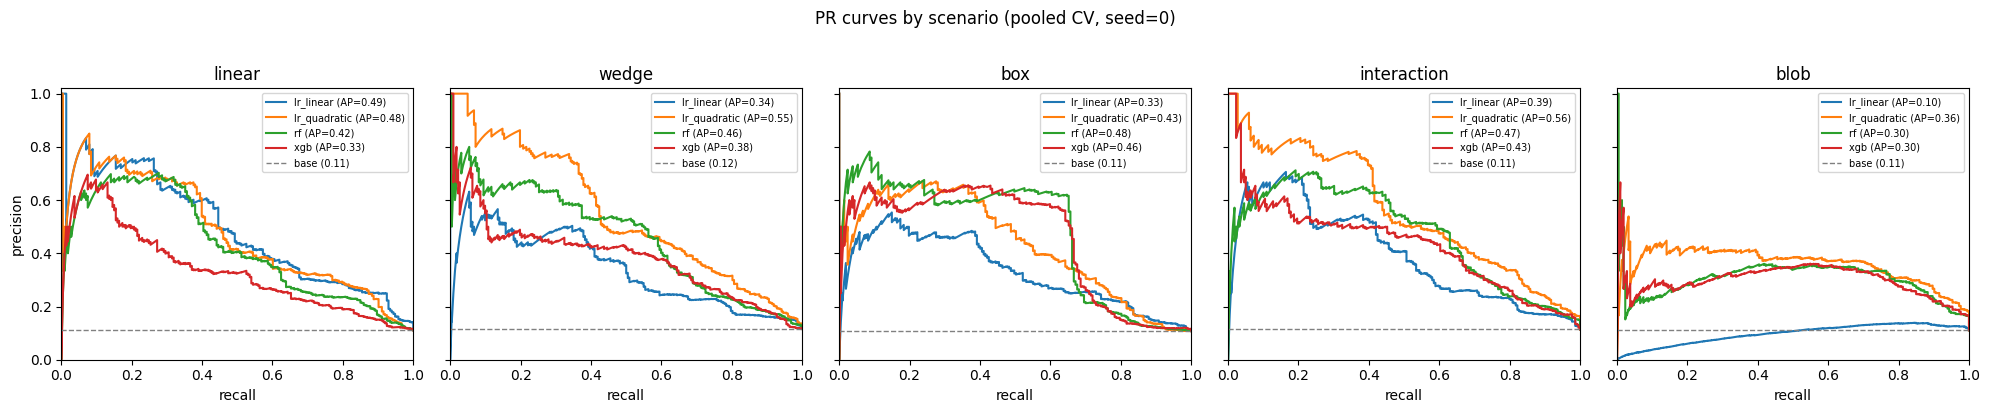

In [7]:
import matplotlib.pyplot as plt
import synth_data as sd
from maser_data import FEATURES, TARGET
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_recall_curve, average_precision_score

def pooled_preds(build, scenario, seed=0):
    """Pool held-out predictions over repeated CV for one model+scenario."""
    d = sd.make_dataset(PLANE, scenario=scenario, strength=STRENGTH, seed=seed)
    X, y = d[FEATS].to_numpy(), d[TGT].to_numpy()
    yp, pp = [], []
    for r in range(OUTER_REPEATS):
        skf = StratifiedKFold(OUTER_SPLITS, shuffle=True, random_state=r)
        for tr, te in skf.split(X, y):
            m = build().fit(X[tr], y[tr])
            yp.append(y[te]); pp.append(m.predict_proba(X[te])[:, 1])
    return np.concatenate(yp), np.concatenate(pp)

def pr_panel(models=MODELS, scenarios=SCENARIOS, seed=0):
    fig, axes = plt.subplots(1, len(scenarios), figsize=(4 * len(scenarios), 4),
                             sharey=True)
    for ax, sc in zip(np.atleast_1d(axes), scenarios):
        base = None
        for name, build in models.items():
            y, p = pooled_preds(build, sc, seed)
            prec, rec, _ = precision_recall_curve(y, p)
            ap = average_precision_score(y, p)
            ax.plot(rec, prec, label=f"{name} (AP={ap:.2f})", linewidth=1.5)
            base = y.mean()
        ax.axhline(base, ls="--", color="gray", lw=1, label=f"base ({base:.2f})")
        ax.set_title(sc); ax.set_xlabel("recall"); ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
        ax.legend(loc="upper right", fontsize=7)
    np.atleast_1d(axes)[0].set_ylabel("precision")
    fig.suptitle(f"PR curves by scenario (pooled CV, seed={seed})", y=1.02)
    plt.tight_layout(); plt.show()

pr_panel()